# 05 — Temperature scaling

**The problem:** ECE = 0.069. The production gate is ECE ≤ 0.04. The model is underconfident — when it says 60% confident, it's actually right ~75% of the time. Accuracy is fine; calibration isn't.

**The fix:** Temperature scaling. Divide the raw logits by a learned scalar `T` before taking softmax. `T < 1` sharpens the distribution (fixes underconfidence). `T > 1` flattens it (fixes overconfidence). Model weights don't change at all.

$$p_\text{calibrated}(y \mid x) = \text{softmax}\left(\frac{z}{T}\right)$$

**Data splits:** We learn `T` on the validation set (already used for checkpoint selection), then evaluate calibration on the held-out test set. This is standard practice for post-hoc calibration.

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy.optimize import minimize_scalar

from data import get_dataloaders
from model import build_model

DATA_DIR    = '../data'
RESULTS_DIR = Path('../results')
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


## Collect logits

Temperature scaling operates on raw logits (pre-softmax), not on probabilities. We collect logits for both the val set (to learn `T`) and the test set (to evaluate).

In [2]:
_, val_loader, test_loader = get_dataloaders(DATA_DIR, batch_size=32)
class_names = val_loader.dataset.classes
num_classes  = len(class_names)

model = build_model(num_classes=num_classes, backbone='resnet50', freeze_backbone=True)
model.load_state_dict(torch.load(RESULTS_DIR / 'v2' / 'best_model.pt', map_location=DEVICE))
model = model.to(DEVICE).eval()
print(f'Loaded checkpoint from {RESULTS_DIR / "v2" / "best_model.pt"}')

Loaded checkpoint from ../results/v2/best_model.pt


In [3]:
def collect_logits(loader, model, device):
    """Returns (logits, labels) as numpy arrays. Logits are pre-softmax."""
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            all_logits.append(model(images.to(device)).cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_logits), np.concatenate(all_labels)

val_logits,  val_labels  = collect_logits(val_loader,  model, DEVICE)
test_logits, test_labels = collect_logits(test_loader, model, DEVICE)

print(f'Val  logits: {val_logits.shape}   Test logits: {test_logits.shape}')

Val  logits: (1120, 7)   Test logits: (1121, 7)


## Learn T on the validation set

We minimize **negative log-likelihood** over the val set as a function of `T`. NLL is the right objective because it directly measures how well the probability distribution matches reality — not just whether the argmax is correct.

$$\text{NLL}(T) = -\frac{1}{n}\sum_{i=1}^{n} \log p_T(y_i \mid x_i)$$

`scipy.optimize.minimize_scalar` does a 1D search over `T`. One parameter, one line of optimization.

In [4]:
def nll(T, logits, labels):
    scaled = torch.tensor(logits / T, dtype=torch.float32)
    log_probs = F.log_softmax(scaled, dim=1)
    return -log_probs[np.arange(len(labels)), labels].mean().item()

result = minimize_scalar(nll, bounds=(0.1, 5.0), method='bounded',
                         args=(val_logits, val_labels))
T_opt = result.x

print(f'Optimal T: {T_opt:.4f}')
print(f'NLL before scaling: {nll(1.0, val_logits, val_labels):.4f}')
print(f'NLL after  scaling: {nll(T_opt, val_logits, val_labels):.4f}')
print()
if T_opt < 1.0:
    print(f'T < 1 → model was underconfident. Scaling sharpens the distribution.')
else:
    print(f'T > 1 → model was overconfident. Scaling flattens the distribution.')

Optimal T: 0.8363
NLL before scaling: 0.8672
NLL after  scaling: 0.8560

T < 1 → model was underconfident. Scaling sharpens the distribution.


T is a single number to divide logits before taking softmax
- before softmax, the model uses unnormalized raw logits
    - softmax converts this into probabilities by exponentiating and normalizing
- T > 1: shrinks the logits toward zero, making distribution flatter. fixes overconfident model
- T < 1: spreads the logits apart, making distribution peaked. fixes underconfident mode
- T = 1: no change. original softmax.

## Evaluate on the test set

`T` was learned on val. Now we apply it to the test logits and recompute ECE. Accuracy should be identical — temperature scaling only changes confidence, not the argmax prediction.

In [5]:
def get_confidences(logits, T=1.0):
    probs = torch.softmax(torch.tensor(logits / T, dtype=torch.float32), dim=1).numpy()
    return probs.max(axis=1), probs.argmax(axis=1)

conf_before, preds_before = get_confidences(test_logits, T=1.0)
conf_after,  preds_after  = get_confidences(test_logits, T=T_opt)

acc_before = (preds_before == test_labels).mean()
acc_after  = (preds_after  == test_labels).mean()
print(f'Test accuracy — before: {acc_before:.4f}  after: {acc_after:.4f}  (should be identical)')
print(f'Mean confidence — before: {conf_before.mean():.4f}  after: {conf_after.mean():.4f}')

Test accuracy — before: 0.7136  after: 0.7136  (should be identical)
Mean confidence — before: 0.6468  after: 0.6934


In [6]:
def reliability_data(confidences, correct, n_bins=10):
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences >= lo) & (confidences < hi if i < n_bins - 1 else confidences <= hi)
        count  = in_bin.sum()
        rows.append({
            'bin_lo':   lo,
            'avg_conf': confidences[in_bin].mean() if count else np.nan,
            'avg_acc':  correct[in_bin].mean()     if count else np.nan,
            'count':    int(count),
        })
    return pd.DataFrame(rows)

correct = (preds_before == test_labels).astype(int)  # same for both since argmax unchanged

rel_before = reliability_data(conf_before, correct)
rel_after  = reliability_data(conf_after,  correct)

def ece(rel):
    ne = rel.dropna(subset=['avg_conf'])
    w  = ne['count'] / ne['count'].sum()
    return (w * (ne['avg_conf'] - ne['avg_acc']).abs()).sum()

ece_before = ece(rel_before)
ece_after  = ece(rel_after)
print(f'ECE before scaling: {ece_before:.4f}')
print(f'ECE after  scaling: {ece_after:.4f}  (target ≤ 0.04)')
print(f'Improvement: {(1 - ece_after / ece_before) * 100:.1f}%')

ECE before scaling: 0.0690
ECE after  scaling: 0.0332  (target ≤ 0.04)
Improvement: 52.0%


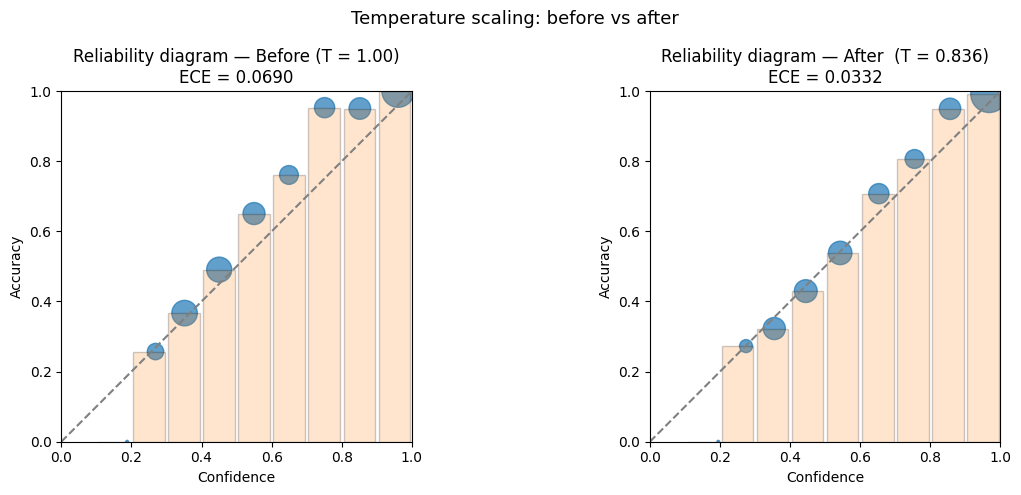

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, rel, label, ece_val in [
    (axes[0], rel_before, 'Before (T = 1.00)', ece_before),
    (axes[1], rel_after,  f'After  (T = {T_opt:.3f})', ece_after),
]:
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
    ne = rel.dropna(subset=['avg_conf'])
    ax.scatter(ne['avg_conf'], ne['avg_acc'], s=ne['count'] * 2, alpha=0.7)
    ax.bar(ne['bin_lo'] + 0.05, ne['avg_acc'], width=0.09, alpha=0.2, edgecolor='black')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Reliability diagram — {label}\nECE = {ece_val:.4f}')
    ax.set_aspect('equal')

plt.suptitle('Temperature scaling: before vs after', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'calibration_temperature_scaling.png', dpi=150)
plt.show()

## Interpretation

**What to look for:**
- Did ECE drop below 0.04?
    - yes. ECE: how far off the model's confidence is from its actual accuracy, dropped to 0.0332 from 0.0690
- Are the points closer to the diagonal in the right plot? Points above the diagonal = underconfident; below = overconfident.
    - points are closer to the diagonal. some are under, some are over.
- Did accuracy stay identical? It must — temperature scaling only rescales probabilities, the argmax doesn't change.
    - ccuracy stayed identical. 0.7136

**Why NLL and not ECE as the optimization objective:**  
ECE depends on bin boundaries (arbitrary), so optimizing it directly overfits to those bins. NLL is a proper scoring rule — optimizing it provably moves you toward the best-calibrated distribution, and it generalizes to the test set. 

**Limitation:**  
We learned `T` on the same val set used for checkpoint selection. Strictly, a separate calibration split would be cleaner. For a 7-class problem with 1120 val images, the risk of overfitting a single scalar is low — but it's worth noting.

**Where temperature scaling fits in the calibration toolkit:**

| Method | Parameters | When to use |
|---|---|---|
| Temperature scaling | 1 | Post-hoc, any model, minimal data needed |
| Platt scaling | 2 per class | Per-class calibration needed |
| Isotonic regression | Many | Large calibration set, non-monotonic miscalibration |

Temperature scaling is almost always the right first choice. It rarely hurts, is hard to overfit, and is trivial to deploy — just store `T` and divide logits before softmax at inference time.